# Particle neighbourhood analysis notebook

This notebook does the following:

0. reads `fcc/particle_data.npz`, `hcp/particle_data.npz`, `liquid/particle_data.npz`
1. sorts the scalar neighbour distances and reorders the neighbour vectors accordingly
2. plots histograms of `w4` and `w6`
3. plots `q4` vs `q6`
4. trains a **simple shallow autoencoder** for:
   - `liquid` vs `fcc`
   - `liquid` vs `fcc` vs `hcp`

for each of:
- `dist`
- `vec_dist`
- `ql`

Additionally, for each autoencoder result, the notebook:
- plots the latent bottleneck
- plots the corresponding `q4` vs `q6` scatter for the same subset
- trains a classifier on the bottleneck and reports the results

All scatter plots use:
- very small point size
- `alpha = 0.2`


In [11]:
# Imports
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [29]:
# Configuration
DATA_DIR = Path(".")
PHASES = ["fcc", "hcp", "liquid"]

LABEL_MAP = {"fcc": 0, "hcp": 1, "liquid": 2}
LABEL_NAMES = {0: "fcc", 1: "hcp", 2: "liquid"}
LABEL_COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

SCATTER_S = 1
SCATTER_ALPHA = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50
BATCH_SIZE = 256
LR = 1e-3
LATENT_DIM = 2

print("Using device:", DEVICE)


Using device: cuda


## 0) Read data

In [ ]:
def load_particle_data(npz_path):
    arr = np.load(npz_path, allow_pickle=True)
    out = {}

    out["dist"] = arr["dist"].astype(np.float32)
    out["w4w6"] = arr["w4w6"].astype(np.float32)
    out["ql"] = arr["ql"].astype(np.float32)
    if "ptm" in arr:
        out["ptm"] = arr["ptm"].astype(np.float32)
    if "cna" in arr:
        out["cna"] = arr["cna"].astype(np.int8)
    if "cna_columns" in arr:
        out["cna_columns"] = arr["cna_columns"]

    vec = arr["vec_dist"]
    if vec.ndim == 3 and vec.shape[2] == 3:
        out["vec_dist"] = vec.astype(np.float32)
    elif vec.ndim == 2 and vec.shape[1] % 3 == 0:
        n_neigh = vec.shape[1] // 3
        out["vec_dist"] = vec.reshape(vec.shape[0], n_neigh, 3).astype(np.float32)
    else:
        raise ValueError(f"Unexpected vec_dist shape in {npz_path}: {vec.shape}")

    return out


In [ ]:
data_by_label = {}

for phase in PHASES:
    f = DATA_DIR / phase / "particle_data.npz"
    if not f.exists():
        raise FileNotFoundError(f"Could not find {f.resolve()}")
    data_by_label[phase] = load_particle_data(f)
    extra = []
    if "ptm" in data_by_label[phase]:
        extra.append(f"ptm {data_by_label[phase]['ptm'].shape}")
    if "cna" in data_by_label[phase]:
        extra.append(f"cna {data_by_label[phase]['cna'].shape}")
    print(
        f"{phase:>6s}: "
        f"dist {data_by_label[phase]['dist'].shape}, "
        f"vec_dist {data_by_label[phase]['vec_dist'].shape}, "
        f"w4w6 {data_by_label[phase]['w4w6'].shape}, "
        f"ql {data_by_label[phase]['ql'].shape}"
        + (", " + ", ".join(extra) if extra else "")
    )


   fcc: dist (180300, 12), vec_dist (180300, 12, 3), w4w6 (180300, 2), ql (180300, 20)
   hcp: dist (180300, 12), vec_dist (180300, 12, 3), w4w6 (180300, 2), ql (180300, 20)
liquid: dist (90300, 12), vec_dist (90300, 12, 3), w4w6 (90300, 2), ql (90300, 20)


## 0b) Sort scalar distances and reorder `vec_dist` accordingly

In [15]:
for phase in PHASES:
    dist = data_by_label[phase]["dist"]      # (N, n_neigh)
    vec = data_by_label[phase]["vec_dist"]   # (N, n_neigh, 3)

    order = np.argsort(dist, axis=1)
    dist_sorted = np.take_along_axis(dist, order, axis=1)
    vec_sorted = np.take_along_axis(vec, order[:, :, None], axis=1)

    data_by_label[phase]["dist"] = dist_sorted
    data_by_label[phase]["vec_dist"] = vec_sorted

print("Sorted dist and reordered vec_dist consistently.")

for phase in PHASES:
    print(f"{phase} first sorted dist row:", data_by_label[phase]["dist"][0])


Sorted dist and reordered vec_dist consistently.
fcc first sorted dist row: [0.92043644 0.97742    0.9993117  1.0039226  1.0280488  1.0335331
 1.0699762  1.078559   1.0791287  1.0814251  1.1210004  1.1269674 ]
hcp first sorted dist row: [0.9457204  0.96150756 0.9749685  1.0259365  1.0331074  1.0346619
 1.0369532  1.037928   1.1045921  1.1270463  1.1374664  1.1472265 ]
liquid first sorted dist row: [0.9447851 1.0108272 1.0149279 1.0184304 1.0450988 1.0636495 1.0831125
 1.1057082 1.1422111 1.2987894 1.3146341 1.3553376]


## 1) Row plot: histograms of $w_4$ and $w_6$

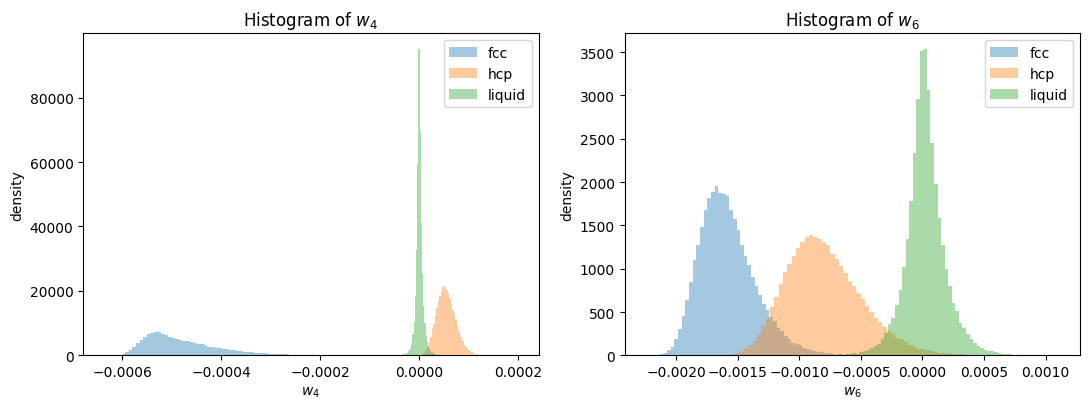

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for phase in PHASES:
    lab = LABEL_MAP[phase]
    w4 = data_by_label[phase]["w4w6"][:, 0]
    w6 = data_by_label[phase]["w4w6"][:, 1]

    axes[0].hist(
        w4, bins=80, density=True, alpha=0.4,
        color=LABEL_COLORS[lab], label=phase
    )
    axes[1].hist(
        w6, bins=80, density=True, alpha=0.4,
        color=LABEL_COLORS[lab], label=phase
    )

axes[0].set_title("Histogram of $w_4$")
axes[0].set_xlabel("$w_4$")
axes[0].set_ylabel("density")
axes[0].legend()

axes[1].set_title("Histogram of $w_6$")
axes[1].set_xlabel("$w_6$")
axes[1].set_ylabel("density")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2) Scatter plot: $q_4$ vs $q_6$ for all three phases

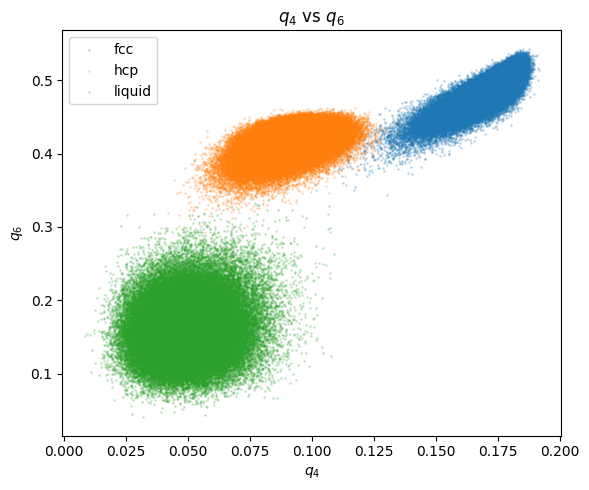

In [30]:
plt.figure(figsize=(6, 5))

for phase in PHASES:
    lab = LABEL_MAP[phase]
    q4 = data_by_label[phase]["ql"][:, 3]
    q6 = data_by_label[phase]["ql"][:, 5]

    plt.scatter(
        q4, q6,
        s=SCATTER_S,
        alpha=SCATTER_ALPHA,
        color=LABEL_COLORS[lab],
        label=phase
    )

plt.xlabel("$q_4$")
plt.ylabel("$q_6$")
plt.title("$q_4$ vs $q_6$")
plt.legend()
plt.tight_layout()
plt.show()


## 3) Simple shallow autoencoder in PyTorch

In [18]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec

    def encode(self, x):
        return self.encoder(x)


## 4) Helpers for data preparation, training, plotting, and classification

In [ ]:
def make_ae_data(data_kind, selected_phases, balance=True, seed=42):
    rng = np.random.default_rng(seed)

    Xs = []
    ys = []
    q4s = []
    q6s = []

    # first collect raw arrays phase by phase
    raw = {}
    for phase in selected_phases:
        X = data_by_label[phase][data_kind]

        if data_kind == "vec_dist":
            X = X.reshape(X.shape[0], -1)
        else:
            X = X.reshape(X.shape[0], -1)

        q4 = data_by_label[phase]["ql"][:, 3]
        q6 = data_by_label[phase]["ql"][:, 5]

        raw[phase] = {
            "X": X,
            "q4": q4,
            "q6": q6
        }

    # optionally balance by downsampling all phases to the smallest size
    if balance:
        min_count = min(raw[phase]["X"].shape[0] for phase in selected_phases)
        print(f"Balancing classes to {min_count} samples each")

        for phase in selected_phases:
            n = raw[phase]["X"].shape[0]
            idx = rng.choice(n, size=min_count, replace=False)

            X = raw[phase]["X"][idx]
            q4 = raw[phase]["q4"][idx]
            q6 = raw[phase]["q6"][idx]
            y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)

            Xs.append(X)
            ys.append(y)
            q4s.append(q4)
            q6s.append(q6)
    else:
        for phase in selected_phases:
            X = raw[phase]["X"]
            q4 = raw[phase]["q4"]
            q6 = raw[phase]["q6"]
            y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)

            Xs.append(X)
            ys.append(y)
            q4s.append(q4)
            q6s.append(q6)

    X = np.concatenate(Xs, axis=0).astype(np.float32)
    y = np.concatenate(ys, axis=0)
    q4 = np.concatenate(q4s, axis=0).astype(np.float32)
    q6 = np.concatenate(q6s, axis=0).astype(np.float32)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y, q4, q6, scaler


def train_shallow_ae(X, y, latent_dim=2, epochs=50, batch_size=256, lr=1e-3):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y,
        shuffle=True
    )

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t, X_train_t),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_test_t, X_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    model = ShallowAutoencoder(input_dim=X.shape[1], latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)

            opt.zero_grad()
            pred = model(xb)
            loss = criterion(pred, target)
            loss.backward()
            opt.step()

            train_loss += loss.item() * xb.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                pred = model(xb)
                loss = criterion(pred, target)
                val_loss += loss.item() * xb.size(0)

        val_loss /= len(val_loader.dataset)

        hist["loss"].append(train_loss)
        hist["val_loss"].append(val_loss)

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        Z = model.encode(X_t).cpu().numpy()

    return model, hist, Z


def plot_ae_row(results_dict, selected_phases, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]
    nice_titles = {"dist": "distances", "vec_dist": "vectors", "ql": "qls"}

    for ax, kind in zip(axes, kinds):
        Z = results_dict[kind]["Z"]
        y = results_dict[kind]["y"]

        if Z.shape[1] > 2:
            Z_plot = PCA(n_components=2).fit_transform(Z)
        else:
            Z_plot = Z

        for phase in selected_phases:
            lab = LABEL_MAP[phase]
            mask = (y == lab)
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase
            )

        ax.set_title(f"{title_prefix}: {nice_titles[kind]}")
        ax.set_xlabel("z1 / PC1")
        ax.set_ylabel("z2 / PC2")
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels)
    plt.tight_layout()
    plt.show()

def run_classifier_on_latent(Z, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y,
        test_size=0.2,
        random_state=42,
        stratify=y,
        shuffle=True
    )

    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    present_labels = sorted(np.unique(y))
    target_names = [LABEL_NAMES[i] for i in present_labels]

    print(title)
    print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred, labels=present_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 5) Autoencoder for `liquid` vs `fcc`

In [20]:
selected_phases_2 = ["liquid", "fcc"]
ae_results_2 = {}

for kind in ["dist", "vec_dist", "ql"]:
    X_ae, y_ae, q4_ae, q6_ae, scaler = make_ae_data(kind, selected_phases_2)
    model, hist, Z = train_shallow_ae(
        X_ae, y_ae,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR
    )

    ae_results_2[kind] = {
        "X": X_ae,
        "y": y_ae,
        "q4": q4_ae,
        "q6": q6_ae,
        "scaler": scaler,
        "model": model,
        "history": hist,
        "Z": Z
    }


Balancing classes to 90300 samples each
Balancing classes to 90300 samples each
Balancing classes to 90300 samples each


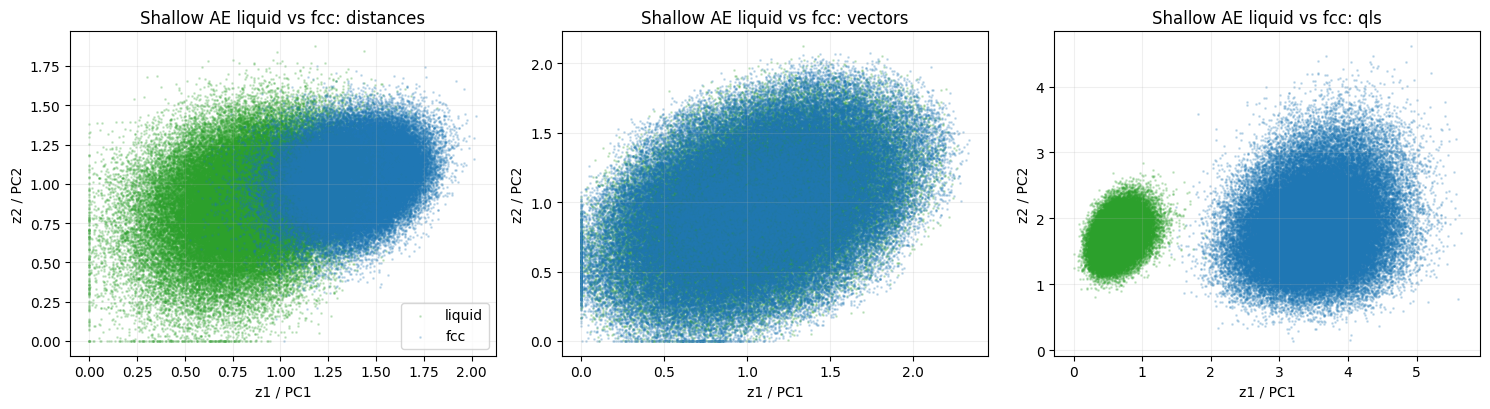

In [31]:
plot_ae_row(ae_results_2, selected_phases_2, "Shallow AE liquid vs fcc")

Classifier on bottleneck | liquid vs fcc | dist
              precision    recall  f1-score   support

         fcc       0.88      0.90      0.89     18060
      liquid       0.90      0.88      0.89     18060

    accuracy                           0.89     36120
   macro avg       0.89      0.89      0.89     36120
weighted avg       0.89      0.89      0.89     36120



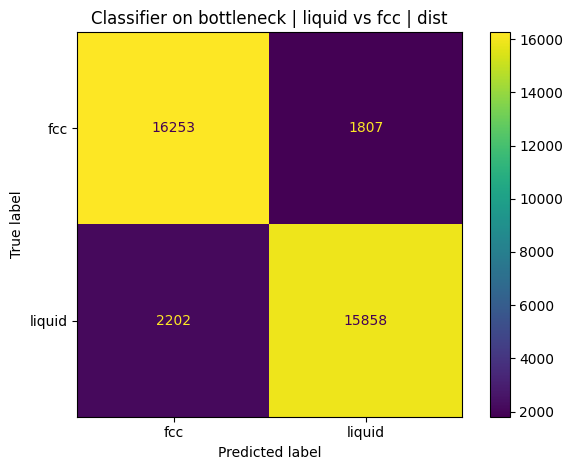

Classifier on bottleneck | liquid vs fcc | vec_dist
              precision    recall  f1-score   support

         fcc       0.50      0.50      0.50     18060
      liquid       0.50      0.50      0.50     18060

    accuracy                           0.50     36120
   macro avg       0.50      0.50      0.50     36120
weighted avg       0.50      0.50      0.50     36120



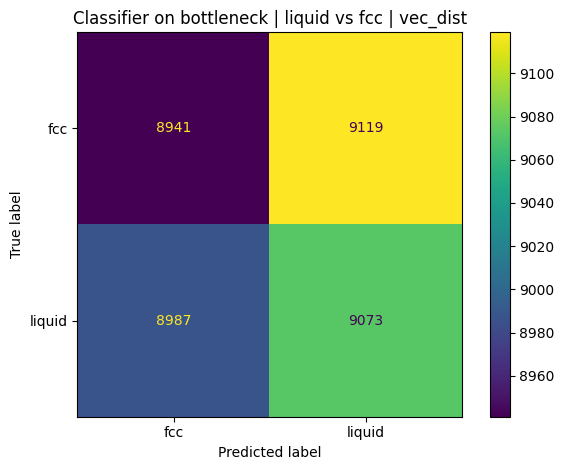

Classifier on bottleneck | liquid vs fcc | ql
              precision    recall  f1-score   support

         fcc       1.00      1.00      1.00     18060
      liquid       1.00      1.00      1.00     18060

    accuracy                           1.00     36120
   macro avg       1.00      1.00      1.00     36120
weighted avg       1.00      1.00      1.00     36120



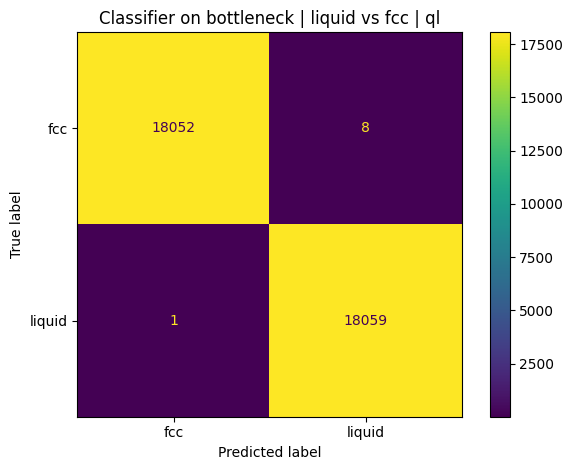

In [23]:
for kind in ["dist", "vec_dist", "ql"]:
    run_classifier_on_latent(
        ae_results_2[kind]["Z"],
        ae_results_2[kind]["y"],
        title=f"Classifier on bottleneck | liquid vs fcc | {kind}"
    )


## 6) Autoencoder for `liquid` vs `fcc` vs `hcp`

In [24]:
selected_phases_3 = ["liquid", "fcc", "hcp"]
ae_results_3 = {}

for kind in ["dist", "vec_dist", "ql"]:
    X_ae, y_ae, q4_ae, q6_ae, scaler = make_ae_data(kind, selected_phases_3)
    model, hist, Z = train_shallow_ae(
        X_ae, y_ae,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR
    )

    ae_results_3[kind] = {
        "X": X_ae,
        "y": y_ae,
        "q4": q4_ae,
        "q6": q6_ae,
        "scaler": scaler,
        "model": model,
        "history": hist,
        "Z": Z
    }


Balancing classes to 90300 samples each
Balancing classes to 90300 samples each
Balancing classes to 90300 samples each


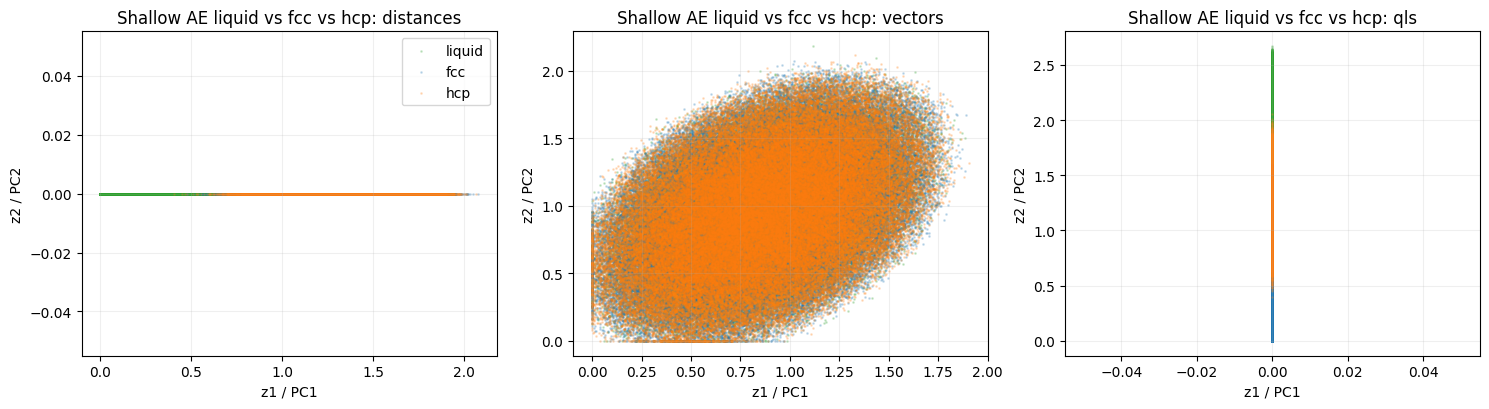

In [33]:
plot_ae_row(ae_results_3, selected_phases_3, "Shallow AE liquid vs fcc vs hcp")

In [40]:
def plot_ae_row_with_randomized(results_dict, selected_phases, title_prefix, noise_scale=0.02):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]
    nice_titles = {"dist": "distances", "vec_dist": "vectors", "ql": "qls"}

    rng = np.random.default_rng(0)

    for ax, kind in zip(axes, kinds):

        Z = results_dict[kind]["Z"]
        y = results_dict[kind]["y"]

        if Z.shape[1] > 2:
            Z = PCA(n_components=2).fit_transform(Z)

        x = Z[:, 0].copy()
        y_lat = Z[:, 1].copy()

        # manual randomization rules
        if kind == "dist":
            y_lat = rng.normal(0, noise_scale, size=len(y_lat))

        elif kind == "ql":
            x = rng.normal(0, noise_scale, size=len(x))

        # vec_dist stays unchanged

        for phase in selected_phases:
            lab = LABEL_MAP[phase]
            mask = (y == lab)

            ax.scatter(
                x[mask],
                y_lat[mask],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase
            )

        ax.set_title(f"{title_prefix}: {nice_titles[kind]}")
        ax.set_xlabel("latent dim 1")
        ax.set_ylabel("latent dim 2")
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels)

    plt.tight_layout()
    plt.show()

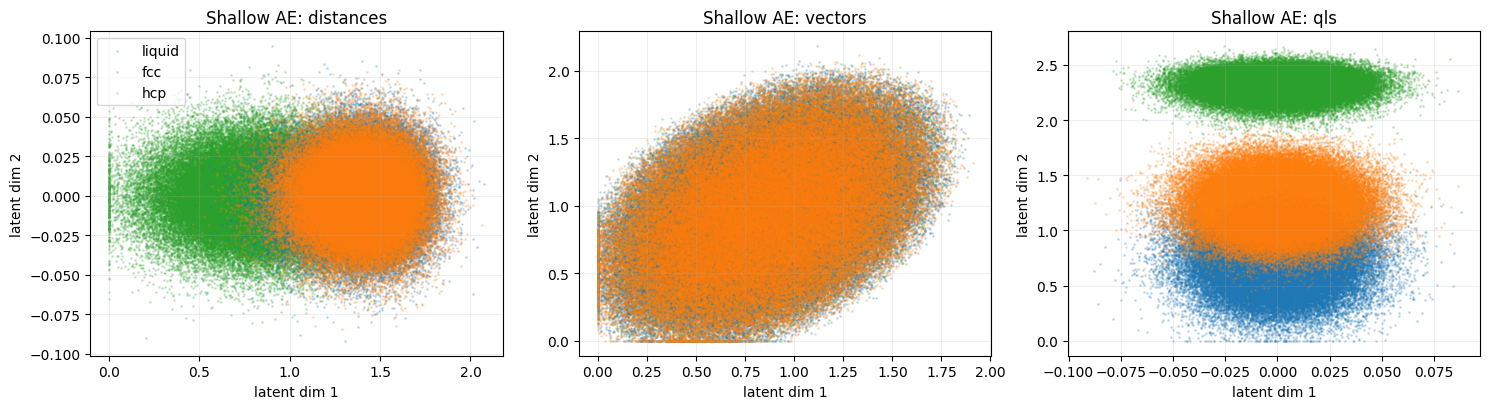

In [41]:
plot_ae_row_with_randomized(ae_results_3, selected_phases_3, "Shallow AE", noise_scale=0.02)


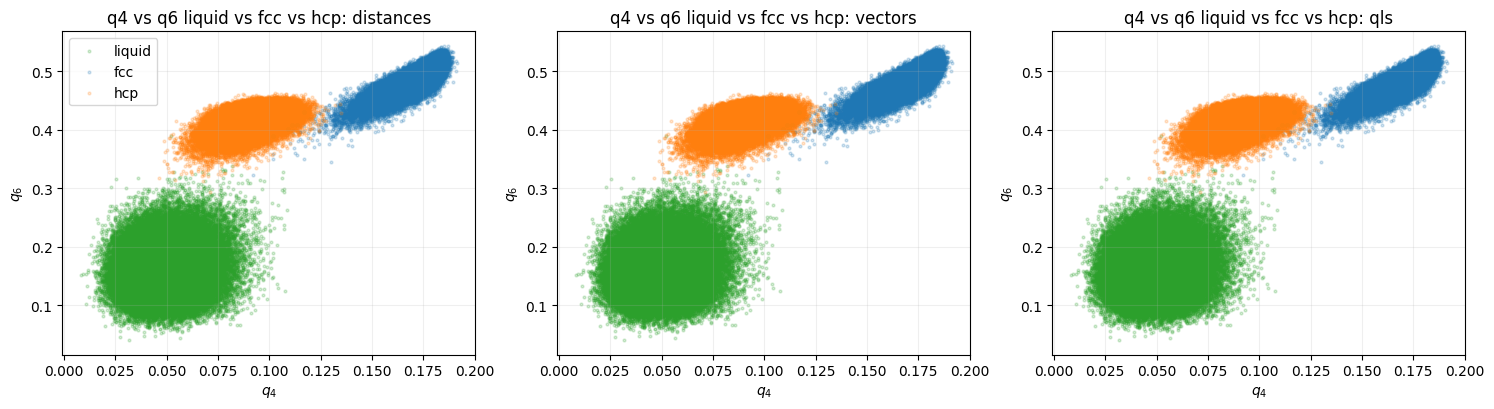

In [26]:
plot_q4q6_row(ae_results_3, selected_phases_3, "q4 vs q6 liquid vs fcc vs hcp")

Classifier on bottleneck | liquid vs fcc vs hcp | dist
              precision    recall  f1-score   support

         fcc       0.44      0.37      0.40     18060
         hcp       0.49      0.53      0.51     18060
      liquid       0.81      0.88      0.84     18060

    accuracy                           0.59     54180
   macro avg       0.58      0.59      0.59     54180
weighted avg       0.58      0.59      0.59     54180



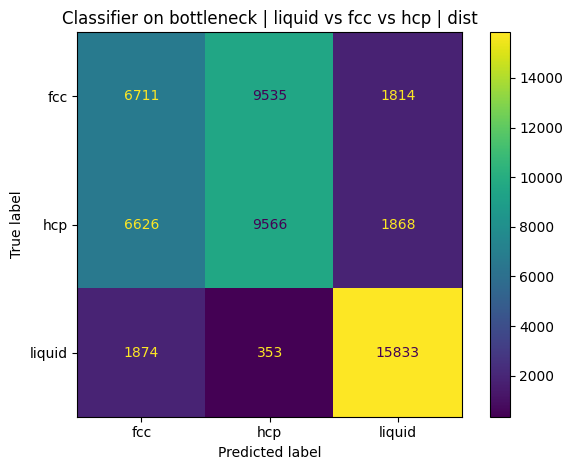

Classifier on bottleneck | liquid vs fcc vs hcp | vec_dist
              precision    recall  f1-score   support

         fcc       0.33      0.37      0.35     18060
         hcp       0.34      0.37      0.35     18060
      liquid       0.33      0.26      0.29     18060

    accuracy                           0.33     54180
   macro avg       0.33      0.33      0.33     54180
weighted avg       0.33      0.33      0.33     54180



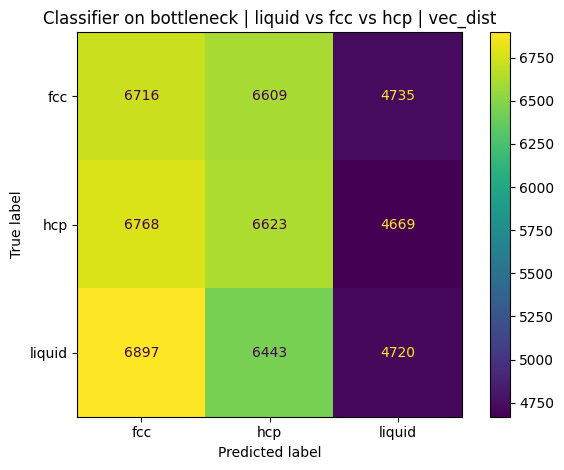

Classifier on bottleneck | liquid vs fcc vs hcp | ql
              precision    recall  f1-score   support

         fcc       0.85      0.83      0.84     18060
         hcp       0.83      0.86      0.84     18060
      liquid       1.00      1.00      1.00     18060

    accuracy                           0.90     54180
   macro avg       0.90      0.90      0.90     54180
weighted avg       0.90      0.90      0.90     54180



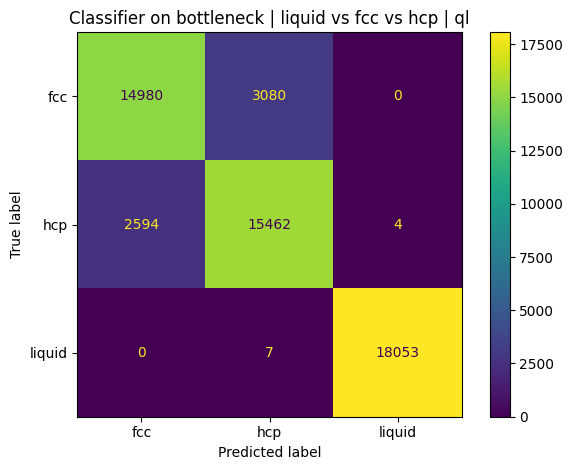

In [27]:
for kind in ["dist", "vec_dist", "ql"]:
    run_classifier_on_latent(
        ae_results_3[kind]["Z"],
        ae_results_3[kind]["y"],
        title=f"Classifier on bottleneck | liquid vs fcc vs hcp | {kind}"
    )


## 7) Training curves

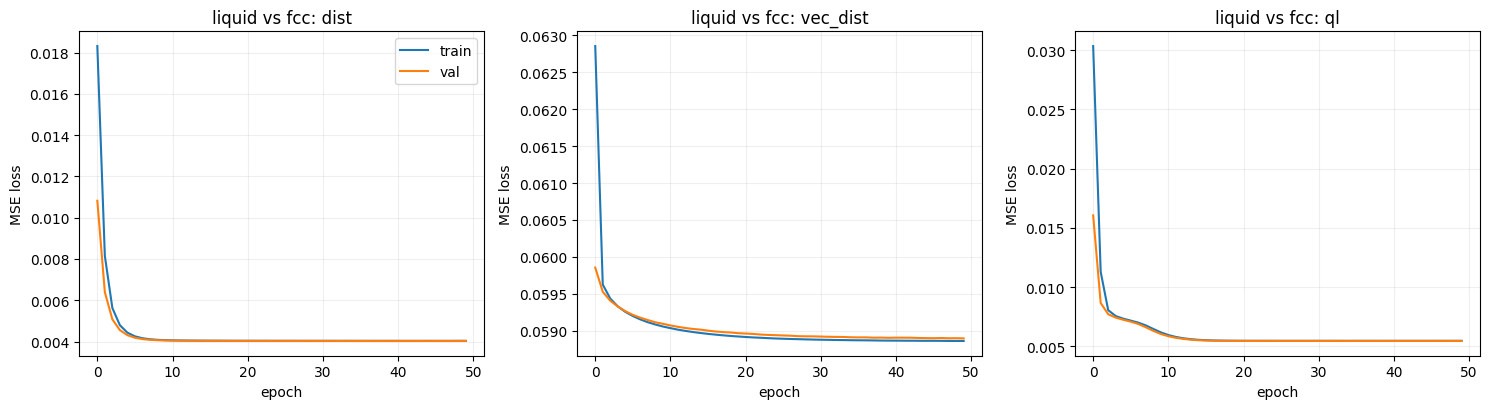

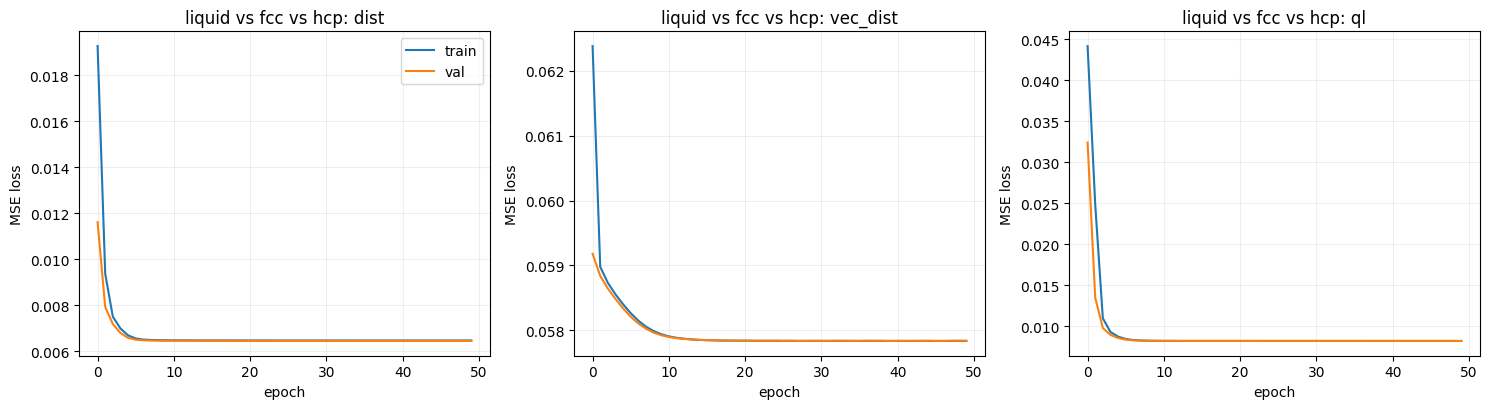

In [43]:
def plot_training_curves(results_dict, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]

    for ax, kind in zip(axes, kinds):
        hist = results_dict[kind]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{title_prefix}: {kind}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE loss")
        ax.grid(alpha=0.2)

    axes[0].legend()
    plt.tight_layout()
    plt.show()

# Examples:
plot_training_curves(ae_results_2, "liquid vs fcc")
plot_training_curves(ae_results_3, "liquid vs fcc vs hcp")
